# Entrenamiento modelo final con todo el histórico:

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import pickle

PROJECT = Path.home() / "Documents" / "rinde-soja"
df = pd.read_csv(PROJECT / "data" / "processed" / "dataset_modelado_soja.csv")

META_COLS = ["campana", "partido", "rinde_qq_ha", "superficie_sembrada_ha", "superficie_cosechada_ha"]
VENTANAS = ["oct_nov", "oct_dic", "oct_ene", "oct_feb", "oct_mar"]

PARTIDOS = {
    "General Arenales": {"lat": -34.31, "lon": -61.10},
    "Leandro N. Alem":  {"lat": -34.52, "lon": -61.38},
    "Junín":            {"lat": -34.59, "lon": -60.95},
    "Lincoln":          {"lat": -34.87, "lon": -61.53},
    "General Pinto":    {"lat": -34.76, "lon": -61.89},
}

def get_features_ventana(ventana):
    idx = VENTANAS.index(ventana)
    ventanas_disponibles = VENTANAS[:idx+1]
    return [c for c in df.columns if c not in META_COLS
            and any(c.endswith(v) for v in ventanas_disponibles)]

# Entrenar un modelo por ventana con TODO el histórico
modelos = {}
scalers = {}

for ventana in VENTANAS:
    features = get_features_ventana(ventana)
    scaler = StandardScaler()
    X = scaler.fit_transform(df[features])
    y = df["rinde_qq_ha"].values

    model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    model.fit(X, y)

    modelos[ventana] = model
    scalers[ventana] = scaler
    print(f"Modelo {ventana}: entrenado con {len(df)} observaciones, {len(features)} features")

print("\nModelos listos para predecir")

Modelo oct_nov: entrenado con 125 observaciones, 13 features
Modelo oct_dic: entrenado con 125 observaciones, 26 features
Modelo oct_ene: entrenado con 125 observaciones, 39 features
Modelo oct_feb: entrenado con 125 observaciones, 52 features
Modelo oct_mar: entrenado con 125 observaciones, 65 features

Modelos listos para predecir


# Descarga clima de la campaña actual:

In [2]:
import requests
import time

# ============================================================
# CONFIGURACIÓN: CAMPAÑA A PREDECIR
# ============================================================
CAMPANA = 2025  # Campaña 2025/26: siembra Oct 2025, cosecha Abr 2026

FECHA_INICIO = f"{CAMPANA}0901"  # Sep del año de siembra
FECHA_FIN = f"{CAMPANA+1}0430"    # Abr del año siguiente

# Si estamos MID-CAMPAIGN (ej: corriendo en enero), NASA POWER
# solo tiene datos hasta la fecha actual. No hay problema,
# el script toma lo que haya disponible.

print(f"Descargando clima para campaña {CAMPANA}/{CAMPANA+1}...")

PARAMS = "T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,ALLSKY_SFC_SW_DWN,RH2M,T2MDEW"
BASE_URL = "https://power.larc.nasa.gov/api/temporal/daily/point"

clima_nueva = []

for partido, coords in PARTIDOS.items():
    print(f"  {partido}...", end=" ", flush=True)
    url = (
        f"{BASE_URL}?"
        f"parameters={PARAMS}"
        f"&community=AG"
        f"&longitude={coords['lon']}"
        f"&latitude={coords['lat']}"
        f"&start={FECHA_INICIO}"
        f"&end={FECHA_FIN}"
        f"&format=JSON"
    )
    resp = requests.get(url, timeout=120)
    data = resp.json()

    dfp = pd.DataFrame(data["properties"]["parameter"])
    dfp.index.name = "fecha"
    dfp = dfp.reset_index().rename(columns={"index": "fecha"})
    dfp["partido"] = partido
    dfp["fecha"] = pd.to_datetime(dfp["fecha"], format="%Y%m%d")

    # Limpiar missings de NASA
    for col in ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","ALLSKY_SFC_SW_DWN","RH2M","T2MDEW"]:
        dfp[col] = dfp[col].replace(-999, np.nan)

    clima_nueva.append(dfp)
    print(f"OK — {len(dfp)} días")
    time.sleep(2)

df_clima_nueva = pd.concat(clima_nueva, ignore_index=True)
print(f"\nClima descargado: {df_clima_nueva['fecha'].min().date()} a {df_clima_nueva['fecha'].max().date()}")

Descargando clima para campaña 2025/2026...
  General Arenales... OK — 242 días
  Leandro N. Alem... OK — 242 días
  Junín... OK — 242 días
  Lincoln... OK — 242 días
  General Pinto... OK — 242 días

Clima descargado: 2025-09-01 a 2026-04-30


# Descarga de NDVI de la campaña actual:

In [3]:
import ee
ee.Initialize(project='rinde-soja')

admin2 = ee.FeatureCollection("FAO/GAUL/2015/level2")
buenos_aires = admin2.filter(ee.Filter.eq("ADM1_NAME", "Buenos Aires"))

# Nuestros partidos (Junin sin tilde en la base FAO)
nombres_gaul = ["General Arenales", "Leandro N. Alem", "Junin", "Lincoln", "General Pinto"]
partidos_fc = buenos_aires.filter(ee.Filter.inList("ADM2_NAME", nombres_gaul))

fecha_ini = f"{CAMPANA}-09-01"
fecha_fin = f"{CAMPANA+1}-04-30"

modis = ee.ImageCollection("MODIS/061/MOD13Q1") \
    .filterDate(fecha_ini, fecha_fin) \
    .select("NDVI")

print(f"Descargando NDVI para campaña {CAMPANA}/{CAMPANA+1}...")
n_images = modis.size().getInfo()
print(f"Imágenes disponibles: {n_images}")

def extract_ndvi(image):
    date = image.date().format("YYYY-MM-dd")
    means = image.reduceRegions(
        collection=partidos_fc,
        reducer=ee.Reducer.mean(),
        scale=250
    )
    return means.map(lambda f: f.set("fecha", date))

results = modis.map(extract_ndvi).flatten()
data = results.getInfo()

ndvi_records = []
nombre_map = {"Junin": "Junín"}  # Corregir tilde

for feat in data["features"]:
    props = feat["properties"]
    nombre = props.get("ADM2_NAME")
    ndvi_records.append({
        "fecha": props.get("fecha"),
        "partido": nombre_map.get(nombre, nombre),
        "ndvi": props.get("mean", np.nan) * 0.0001,
    })

df_ndvi_nueva = pd.DataFrame(ndvi_records)
df_ndvi_nueva["fecha"] = pd.to_datetime(df_ndvi_nueva["fecha"])
df_ndvi_nueva = df_ndvi_nueva.sort_values(["partido", "fecha"]).reset_index(drop=True)

print(f"NDVI descargado: {df_ndvi_nueva['fecha'].min().date()} a {df_ndvi_nueva['fecha'].max().date()}")
print(f"Registros por partido: {df_ndvi_nueva.groupby('partido').size().to_dict()}")

Descargando NDVI para campaña 2025/2026...
Imágenes disponibles: 15
NDVI descargado: 2025-09-14 a 2026-04-23
Registros por partido: {'General Arenales': 15, 'General Pinto': 15, 'Junín': 15, 'Leandro N. Alem': 15, 'Lincoln': 15}


# Construcción de features de la campaña actual:

In [4]:
def mes_campana(fecha, campana):
    if fecha.year == campana:
        return fecha.month
    elif fecha.year == campana + 1:
        return fecha.month + 12
    return None

VENTANAS_DEF = {
    "oct_nov": (10, 11),
    "oct_dic": (10, 12),
    "oct_ene": (10, 13),
    "oct_feb": (10, 14),
    "oct_mar": (10, 15),
}

# Preparar clima
df_clima_nueva["mes_camp"] = df_clima_nueva["fecha"].apply(lambda f: mes_campana(f, CAMPANA))

# Preparar NDVI
df_ndvi_nueva["mes_camp"] = df_ndvi_nueva["fecha"].apply(lambda f: mes_campana(f, CAMPANA))

# Determinar hasta qué ventana tenemos datos
ultimo_mes_clima = df_clima_nueva["mes_camp"].max()
ultimo_mes_ndvi = df_ndvi_nueva["mes_camp"].max()
ultimo_mes = min(ultimo_mes_clima, ultimo_mes_ndvi)

ventanas_disponibles = [v for v, (ini, fin) in VENTANAS_DEF.items() if fin <= ultimo_mes]
print(f"Último mes con datos: {ultimo_mes} → ventanas disponibles: {ventanas_disponibles}")

# Construir features
rows_nueva = []
for partido in PARTIDOS.keys():
    row = {"campana": CAMPANA, "partido": partido}

    dc = df_clima_nueva[df_clima_nueva["partido"] == partido]
    dn = df_ndvi_nueva[df_ndvi_nueva["partido"] == partido]

    for ventana_nombre, (mes_ini, mes_fin) in VENTANAS_DEF.items():
        dv_c = dc[(dc["mes_camp"] >= mes_ini) & (dc["mes_camp"] <= mes_fin)]
        dv_n = dn[(dn["mes_camp"] >= mes_ini) & (dn["mes_camp"] <= mes_fin)]

        if len(dv_c) == 0:
            continue

        row[f"precip_acum_{ventana_nombre}"] = dv_c["PRECTOTCORR"].sum()
        row[f"temp_media_{ventana_nombre}"] = dv_c["T2M"].mean()
        row[f"temp_max_media_{ventana_nombre}"] = dv_c["T2M_MAX"].mean()
        row[f"temp_min_media_{ventana_nombre}"] = dv_c["T2M_MIN"].mean()
        row[f"rad_media_{ventana_nombre}"] = dv_c["ALLSKY_SFC_SW_DWN"].mean()
        row[f"humedad_media_{ventana_nombre}"] = dv_c["RH2M"].mean()
        row[f"dias_calor_extremo_{ventana_nombre}"] = (dv_c["T2M_MAX"] > 35).sum()
        row[f"dias_sin_lluvia_{ventana_nombre}"] = (dv_c["PRECTOTCORR"] < 1).sum()

        if len(dv_n) > 0:
            row[f"ndvi_mean_{ventana_nombre}"] = dv_n["ndvi"].mean()
            row[f"ndvi_max_{ventana_nombre}"] = dv_n["ndvi"].max()
            row[f"ndvi_min_{ventana_nombre}"] = dv_n["ndvi"].min()
            row[f"ndvi_std_{ventana_nombre}"] = dv_n["ndvi"].std()
            if len(dv_n) >= 2:
                x = np.arange(len(dv_n))
                slope = np.polyfit(x, dv_n["ndvi"].values, 1)[0]
                row[f"ndvi_slope_{ventana_nombre}"] = slope

    rows_nueva.append(row)

df_nueva = pd.DataFrame(rows_nueva)
print(f"\nFeatures construidas: {df_nueva.shape}")

Último mes con datos: 16 → ventanas disponibles: ['oct_nov', 'oct_dic', 'oct_ene', 'oct_feb', 'oct_mar']

Features construidas: (5, 67)


# Predecir y mostrar resultados:

In [5]:
# Usar la ventana más completa disponible
ventana_usar = ventanas_disponibles[-1]
features = get_features_ventana(ventana_usar)

# Verificar que tenemos todas las features necesarias
features_disponibles = [f for f in features if f in df_nueva.columns]
features_faltantes = [f for f in features if f not in df_nueva.columns]

if features_faltantes:
    print(f"AVISO: faltan {len(features_faltantes)} features: {features_faltantes[:5]}...")
    print("Usando solo las disponibles")
    features = features_disponibles

X_nueva = scalers[ventana_usar].transform(df_nueva[features])
predicciones = modelos[ventana_usar].predict(X_nueva)

df_nueva["rinde_predicho"] = predicciones.round(1)

# Promedio histórico por partido (para referencia)
hist_promedio = df.groupby("partido")["rinde_qq_ha"].mean().round(1)

print(f"\n{'='*60}")
print(f"PREDICCIÓN CAMPAÑA {CAMPANA}/{CAMPANA+1}")
print(f"Ventana utilizada: {ventana_usar}")
print(f"{'='*60}\n")

for _, row in df_nueva.iterrows():
    partido = row["partido"]
    pred = row["rinde_predicho"]
    prom_hist = hist_promedio[partido]
    diff_pct = ((pred - prom_hist) / prom_hist * 100)
    estado = "🟢 ARRIBA" if diff_pct > 5 else "🔴 ABAJO" if diff_pct < -5 else "🟡 NORMAL"

    print(f"  {partido:22s} | Predicción: {pred:5.1f} qq/ha | Promedio hist: {prom_hist:5.1f} | {estado} ({diff_pct:+.1f}%)")

promedio_zona = df_nueva["rinde_predicho"].mean()
print(f"\n  {'PROMEDIO ZONA':22s} | Predicción: {promedio_zona:.1f} qq/ha")


PREDICCIÓN CAMPAÑA 2025/2026
Ventana utilizada: oct_mar

  General Arenales       | Predicción:  36.2 qq/ha | Promedio hist:  33.8 | 🟢 ARRIBA (+7.1%)
  Leandro N. Alem        | Predicción:  35.1 qq/ha | Promedio hist:  30.9 | 🟢 ARRIBA (+13.6%)
  Junín                  | Predicción:  33.7 qq/ha | Promedio hist:  32.4 | 🟡 NORMAL (+4.0%)
  Lincoln                | Predicción:  32.2 qq/ha | Promedio hist:  29.0 | 🟢 ARRIBA (+11.0%)
  General Pinto          | Predicción:  32.3 qq/ha | Promedio hist:  29.4 | 🟢 ARRIBA (+9.9%)

  PROMEDIO ZONA          | Predicción: 33.9 qq/ha


# Gráfico de la predicción en contexto histórico:

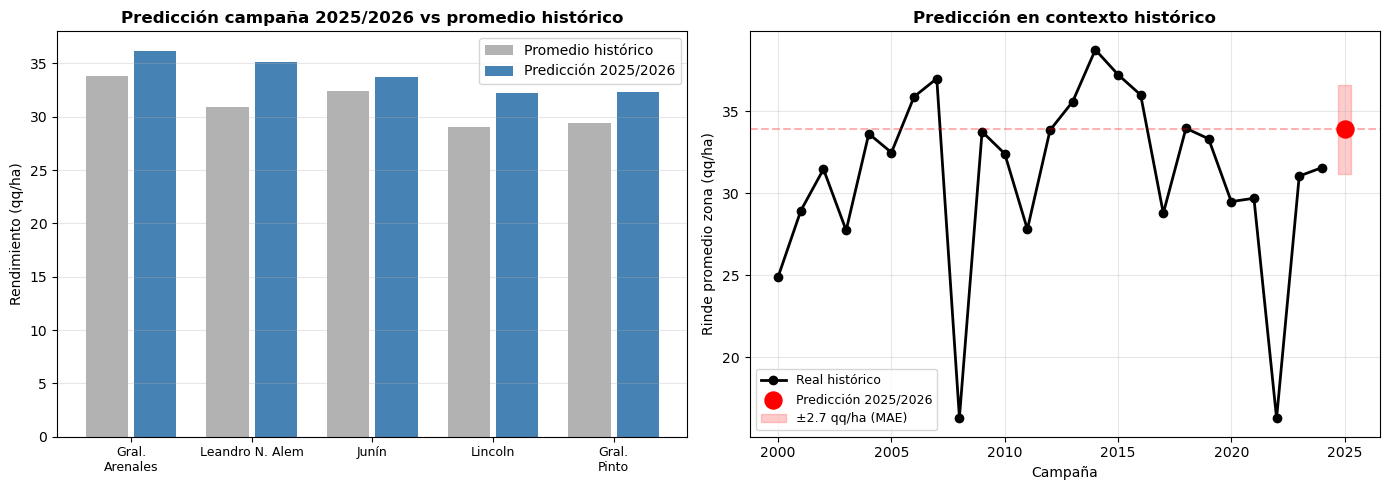

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Predicción por partido vs promedio histórico
ax = axes[0]
partidos_list = df_nueva["partido"].tolist()
pred_vals = df_nueva["rinde_predicho"].tolist()
hist_vals = [hist_promedio[p] for p in partidos_list]

x = np.arange(len(partidos_list))
ax.bar(x - 0.2, hist_vals, 0.35, label="Promedio histórico", color="gray", alpha=0.6)
ax.bar(x + 0.2, pred_vals, 0.35, label=f"Predicción {CAMPANA}/{CAMPANA+1}", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels([p.replace("General ", "Gral.\n") for p in partidos_list], fontsize=9)
ax.set_ylabel("Rendimiento (qq/ha)")
ax.set_title(f"Predicción campaña {CAMPANA}/{CAMPANA+1} vs promedio histórico", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# 2. Serie temporal con la predicción nueva
ax = axes[1]
hist_zona = df.groupby("campana")["rinde_qq_ha"].mean()
ax.plot(hist_zona.index, hist_zona.values, marker="o", linewidth=2, color="black", label="Real histórico")
ax.scatter(CAMPANA, promedio_zona, color="red", s=150, zorder=5, label=f"Predicción {CAMPANA}/{CAMPANA+1}")
ax.axhline(y=promedio_zona, color="red", linestyle="--", alpha=0.3)
ax.fill_between([CAMPANA-0.3, CAMPANA+0.3], promedio_zona-2.7, promedio_zona+2.7, alpha=0.2, color="red", label="±2.7 qq/ha (MAE)")
ax.set_xlabel("Campaña")
ax.set_ylabel("Rinde promedio zona (qq/ha)")
ax.set_title("Predicción en contexto histórico", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()